In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from scipy.stats import zscore
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error,
    r2_score,
)
from scipy.stats import pearsonr
import os

def metrics(method, y_test, y_pred):
    """
    Outputs classification metrics
    """
    #config_path = os.path.join(os.path.dirname(__file__), "../config.yaml")
    #with open(config_path) as f:
    #    config = yaml.safe_load(f)
    
    corr, p_value = pearsonr(y_test, y_pred)
    print(f'{method}. Classification metrics:\n')
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
    print(f"R²: {r2_score(y_test, y_pred)}")
    print(f"Pearson correlation coefficient: {corr}, p-value: {p_value}\n")
    
    return r2_score(y_test, y_pred)
    

In [3]:
def split_data(descriptors_path, features_file, method='RandomForestRegressor', test_size=0.1, random_state=18):

    data = pd.read_csv(descriptors_path)
    data = data.dropna()
    
    features = pd.read_csv(features_file)
    RF_features = features['RF']
    DT_features = features['DT']
    GB_features = features['GB']

    feature_sets = {"RandomForestRegressor": RF_features, 
                    "DecisionTreeRegressor": DT_features,
                   "GradientBoostingRegressor": GB_features}
    
    # Selection of specified features and target variable
    features = feature_sets[method]
    X = data[features]  # Selected features
    
    z_scores = zscore(X)
    X_filtered = X[(z_scores < 3).all(axis=1)]
    y_filtered = data.loc[X_filtered.index, "pIC50"].str.replace(',', '.').astype(float)
    
    # Нормализация данных
    categorial_col = [col for col in X_filtered.columns if X_filtered[col].nunique() == 2 and int(X_filtered[col].max())==1]
    numeric_col = [col for col in X_filtered.columns if not(X_filtered[col].nunique() == 2 and int(X_filtered[col].max())==1)]
    
    # categorial_col = [col for col in X.columns if X[col].nunique() == 2 and int(X[col].max())==1]
    # numeric_col = [col for col in X.columns if not(X[col].nunique() == 2 and int(X[col].max())==1)]
    preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_col),
        ('cat', 'passthrough', categorial_col) 
    ])

    X_scaled = preprocessor.fit_transform(X)

    # Преобразуем результат обратно в DataFrame (опционально)
    X_scaled = pd.DataFrame(X_scaled, columns=numeric_col + categorial_col)
    # scaler = StandardScaler()
    # X = scaler.fit_transform(X)
    y = data["pIC50"]  # Target value
    y = y.str.replace(',', '.').astype(float)
    
    # Разделение данных на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)
    
    return X_train, X_test, y_train, y_test

In [4]:
X_train, X_test, y_train, y_test = split_data('NS3_4A_descriptors.csv', 'my_features_NS3_4A.csv', method='RandomForestRegressor')

In [144]:
from sklearn.svm import SVR

def support_vector_regression(X_train, X_test, y_train, y_test):
    
    svr = SVR()

    # Parameters for selection
    param_grid = {
        'kernel': ['rbf'],
        'C': [0.1, 1],  # Regularization parameter
        'gamma': [0.0001, 0.001],  # Core coefficient
        'epsilon': [0.01, 0.1]  
    }
    
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18)
    # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print(f"Best parametrs: {grid_search.best_params_} \n")
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("Support vector regression", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("Support vector regression", y_train, grid_search.predict(X_train))
    
    #return test_metric, train_metric
    return grid_search
    


In [14]:
svr_test_metric, svr_train_metric = support_vector_regression(X_train, X_test, y_train, y_test)

Best parametrs: {'C': 1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'} 

_______________________________________________________________
Test metrics
Support vector regression. Classification metrics:

MAE: 0.7086949810034057
RMSE: 0.9446276172429557
R²: 0.6709799761528403
Pearson correlation coefficient: 0.8678940463545327, p-value: 6.92962351731168e-16

_______________________________________________________________
Train metrics
Support vector regression. Classification metrics:

MAE: 0.6470672272669461
RMSE: 0.86851051466433
R²: 0.6489144687829331
Pearson correlation coefficient: 0.8124274730419723, p-value: 3.337065526107072e-104



In [7]:
def plot_svr_decision_boundary(model, pca, X, y, model_name, filepath):
    X_pca = pca.transform(X)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_original = pca.inverse_transform(grid_points) # reverse transformation

    Z = model.predict(grid_points_original)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'{model_name} Decision Boundary with PCA')
    plt.colorbar()
    plt.savefig(filepath)
    plt.show()

In [10]:
from sklearn.svm import SVR

In [11]:
pca = PCA(n_components=2)
pca.fit(X_train)

svr = SVR(kernel='rbf', C=1, epsilon=0.01, gamma=0.001)
svr.fit(X_train, y_train)

SVR(C=1, epsilon=0.01, gamma=0.001)

/home/pgurzhii/miniforge3/envs/boosting/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


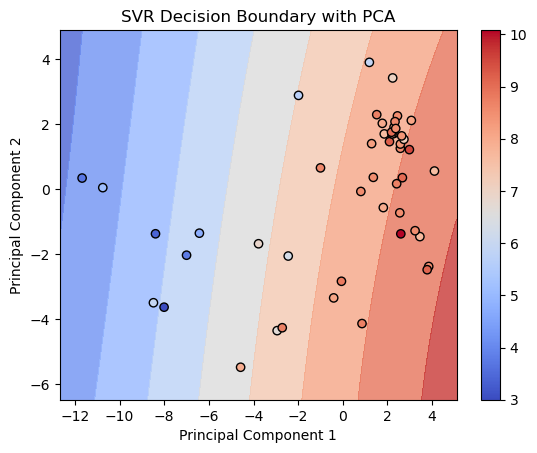

In [9]:
plot_svr_decision_boundary(svr, pca, X_test, y_test, 'SVR', 'Plots/SVR Decision Boundary')

In [10]:
from sklearn.neighbors import KNeighborsRegressor

def k_Nearest_Neighbour(X_train, X_test, y_train, y_test):
    
    knn = KNeighborsRegressor()
    
    # Parameters for selection
    param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
    }
    
    # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=knn,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',  # Optimization metric
        cv=10,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("k Nearest Neighbour", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("k Nearest Neighbour", y_train, grid_search.predict(X_train))
    
    #return test_metric, train_metric
    return grid_search
    

In [15]:
knn_test_metric, knn_train_metric = k_Nearest_Neighbour(X_train, X_test, y_train, y_test)

Best parametrs: {'n_neighbors': 7}
_______________________________________________________________
Test metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.5206848560349854
RMSE: 0.6809904897697109
R²: 0.8290051044330724
Pearson correlation coefficient: 0.9109282503848231, p-value: 1.0725791919073911e-19

_______________________________________________________________
Train metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.43689284508056103
RMSE: 0.6051451348542097
R²: 0.8295559430723842
Pearson correlation coefficient: 0.912606380478378, p-value: 1.813120949734912e-171



/home/pgurzhii/miniforge3/envs/boosting/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


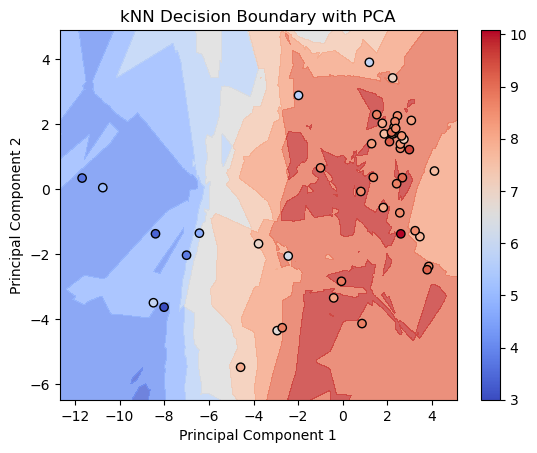

In [11]:
kNN = KNeighborsRegressor(n_neighbors=7)
kNN.fit(X_train, y_train)

plot_svr_decision_boundary(kNN, pca, X_test, y_test, 'kNN', 'Plots/kNN Decision Boundary')

In [5]:
from sklearn.neural_network import MLPRegressor

def MLP_regressor(X_train, X_test, y_train, y_test):
    
    #mlp = MLPRegressor()
    mlp = MLPRegressor(early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,
    max_iter=50000)
    
    param_grid = {
    'hidden_layer_sizes': [(2,), (5,)],
    #'activation': ['logistic', 'tanh','relu'],
    #'solver': ['sgd', 'adam'],
    'learning_rate': ['adaptive'],
    'alpha': [0.1, 0.5, 1],
    'learning_rate_init': [0.00001, 0.00005],
    'max_iter': [50000]
}
    
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=18)
     # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("Multi-layer Perceptron regressor", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("Multi-layer Perceptron regressor", y_train, grid_search.predict(X_train))
    
    return test_metric, train_metric

In [16]:
mlp_test_metric, mlp_train_metric = MLP_regressor(X_train, X_test, y_train, y_test)

/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pgurzhii/miniforge3/envs/HCV/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50000) reached and the optimization hasn't converged ye

Best parametrs: {'alpha': 0.5, 'hidden_layer_sizes': (5,), 'learning_rate': 'adaptive', 'learning_rate_init': 5e-05, 'max_iter': 50000}
_______________________________________________________________
Test metrics
Multi-layer Perceptron regressor. Classification metrics:

MAE: 0.7498487713222485
RMSE: 1.0299882348549194
R²: 0.6088299636483503
Pearson correlation coefficient: 0.8051156544549967, p-value: 3.0949992129778474e-12

_______________________________________________________________
Train metrics
Multi-layer Perceptron regressor. Classification metrics:

MAE: 0.7131955722304572
RMSE: 0.9177248265550151
R²: 0.6079984974526864
Pearson correlation coefficient: 0.802345267934492, p-value: 9.067647365378389e-100



/home/pgurzhii/miniforge3/envs/boosting/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


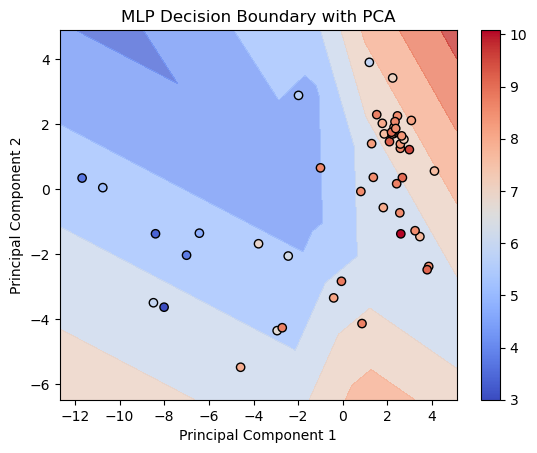

In [12]:
mlp = MLPRegressor(early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,
    max_iter=50000,
    alpha=0.5,
    hidden_layer_sizes=(5,),
    learning_rate='adaptive',
    learning_rate_init=5e-05       
)
mlp.fit(X_train, y_train)

plot_svr_decision_boundary(mlp, pca, X_test, y_test, 'MLP', 'Plots/MLP Decision Boundary')

In [12]:
metrics = pd.DataFrame()
metrics["RF_train"] = svr_train_metric, knn_train_metric, mlp_train_metric
metrics["RF_test"] = svr_test_metric, knn_test_metric, mlp_test_metric
metrics.index = ['SVR', 'kNN', 'MLP'] 

print(metrics)
metrics.to_csv("R2_RF.csv")

     RF_train   RF_test
SVR  0.754311  0.892321
kNN  0.366201  0.463748
MLP  0.630497  0.840746


## Градиентные бустинги

### CatBoost

In [14]:
from catboost import CatBoostRegressor

In [14]:
def CatBoost(X_train, X_test, y_train, y_test):
    model = CatBoostRegressor(verbose=0, thread_count=30)

    param_grid = {
        'iterations': [400], # количество деревьев
        'learning_rate': [0.01],
        'depth': [7],
        'l2_leaf_reg': [20],
        'subsample': [0.7, 0.8, 0.9],  # Добавляем бэггинг
        'random_strength': [1, 2],  # Добавляем случайность
        'early_stopping_rounds': [50]  # Ранняя остановка
    }
    
    # param_grid = {
    # 'iterations': [300, 400],
    # 'learning_rate': [0.01, 0.05],
    # 'depth': [6, 7, 8],
    # 'l2_leaf_reg': [15, 20],
    # 'subsample': [0.7, 0.8, 0.9],
    # 'random_strength': [1, 2],
    # 'early_stopping_rounds': [50]
    # }

    grid_search = GridSearchCV(estimator=model, 
                               param_grid=param_grid,
                               cv=10, 
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)
    print('training...')
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("k Nearest Neighbour", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("k Nearest Neighbour", y_train, grid_search.predict(X_train))
    
    #return test_metric, train_metric
    
CatBoost(X_train, X_test, y_train, y_test)

training...


TBB Warning: The number of workers is currently limited to 31. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 31. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 31. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 31. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 31. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.

TBB Warning: The number of workers is currently limited to 31. Th

Best parametrs: {'depth': 7, 'early_stopping_rounds': 50, 'iterations': 400, 'l2_leaf_reg': 20, 'learning_rate': 0.01, 'random_strength': 1, 'subsample': 0.8}
_______________________________________________________________
Test metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.6407619565721772
RMSE: 0.8207512615834225
R²: 0.7516156833363732
Pearson correlation coefficient: 0.8982492026060171, p-value: 2.1209306188637687e-18

_______________________________________________________________
Train metrics
k Nearest Neighbour. Classification metrics:

MAE: 0.5125966018649436
RMSE: 0.6639328785493175
R²: 0.7948312926144483
Pearson correlation coefficient: 0.9134488266657554, p-value: 2.4134924478752285e-172



TBB Warning: The number of workers is currently limited to 15. The request for 71 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



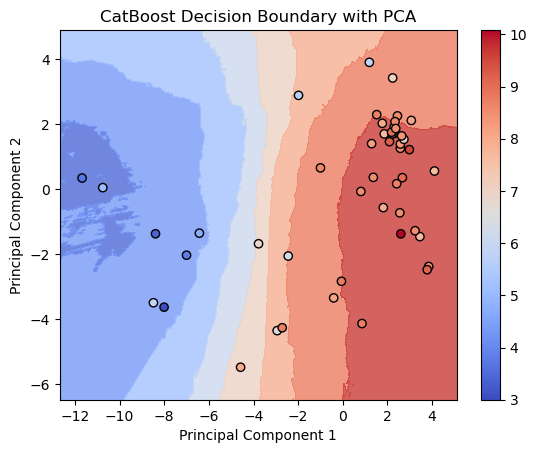

In [15]:
best_params = {'depth': 7, 'early_stopping_rounds': 50, 'iterations': 400, 'l2_leaf_reg': 20, 'learning_rate': 0.01, 'random_strength': 1, 'subsample': 0.8}
model = CatBoostRegressor(verbose=0, thread_count=30, **best_params)
model.fit(X_train, y_train)
plot_svr_decision_boundary(model, pca, X_test, y_test, 'CatBoost', 'CatBoost Decision Boundary')

### XGBoost

In [16]:
from xgboost import XGBRegressor

In [38]:
def XGBoost(X_train, X_test, y_train, y_test):
    model = XGBRegressor()

    param_grid = {
        'n_estimators': [300],
        'learning_rate': [0.01, 0.05],
        'max_depth': [5],
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8],
        'reg_alpha': [30],  # L1 регуляризация
        'reg_lambda': [30]  # L2 регуляризация
    }

    grid_search = GridSearchCV(estimator=model, 
                              param_grid=param_grid,
                              cv=10, 
                              scoring='neg_mean_squared_error',
                              n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Best parameters
    print("Best parameters:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    test_metric = metrics("XGBoost", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    train_metric = metrics("XGBoost", y_train, grid_search.predict(X_train))
    
XGBoost(X_train, X_test, y_train, y_test)

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 30, 'reg_lambda': 30, 'subsample': 0.8}
_______________________________________________________________
Test metrics
XGBoost. Classification metrics:

MAE: 0.5988441964446698
RMSE: 0.7916666387234313
R²: 0.7689075588369461
Pearson correlation coefficient: 0.8915104176168315, p-value: 8.867857019871297e-18

_______________________________________________________________
Train metrics
XGBoost. Classification metrics:

MAE: 0.46170264012718665
RMSE: 0.6351275559018295
R²: 0.8122479524766038
Pearson correlation coefficient: 0.9174817591392681, p-value: 1.154692296469163e-176



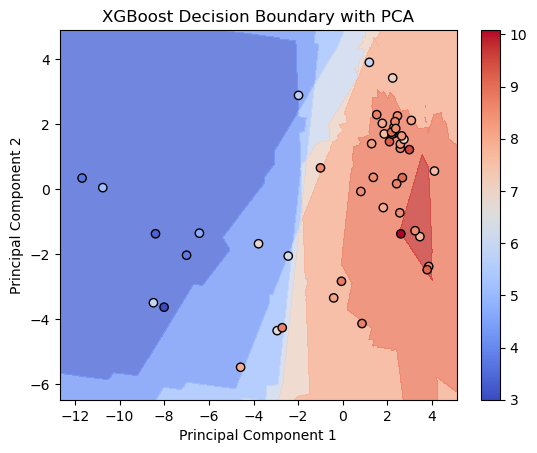

In [17]:
best_params = {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 30, 'reg_lambda': 30, 'subsample': 0.8}
model = XGBRegressor(**best_params)
model.fit(X_train, y_train)
plot_svr_decision_boundary(model, pca, X_test, y_test, 'XGBoost', 'Plots/XGBoost Decision Boundary')

# Оптимизация зазора между train и test

In [18]:
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [137]:
SEED = 37
np.random.seed(SEED)

# Разделение данных на train + validation и test
X_train_val, X_test, y_train_val, y_test = split_data('NS3_4A_descriptors.csv', 'my_features_NS3_4A.csv', method='RandomForestRegressor')

# Дополнительное разбиение train + validation на train и validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=SEED)  # 20% от исходных данных для validation

# Функция для оптимизации гиперпараметров
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.9, 2),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 24, 40),
        'reg_lambda': trial.suggest_float('reg_lambda', 6, 20),
        'n_estimators': trial.suggest_int('n_estimators',900, 1000),
        'early_stopping_rounds': 50,
        'random_state': SEED
    }
    model = xgb.XGBRegressor(objective='reg:squarederror',  # Целевая функция для регрессии
                             **params)
    model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],  # Валидационный набор для ранней остановки
              verbose=False)
    y_val_pred = model.predict(X_val)
    y_train_pred = model.predict(X_train)
    
    # Используем R2 как метрику
    r2_val = r2_score(y_val, y_val_pred)
    r2_train = r2_score(y_train, y_train_pred)
    
    # Штраф за переобучение
    gap = r2_train - r2_val
    penalty = 20  # Коэффициент штрафа
    score = r2_val - penalty * gap  # Минимизируем эту функцию
    return score

# Оптимизация гиперпараметров
study = optuna.create_study(direction='maximize',
                           sampler=optuna.samplers.TPESampler(seed=SEED))  
study.optimize(objective, n_trials=50)

# Лучшие параметры
best_params = study.best_params
print("Best parameters:", best_params)

# Обучение модели с лучшими параметрами на train + validation
best_model = xgb.XGBRegressor(objective='reg:squarederror',
                              random_state=SEED,
                              **best_params)
best_model.fit(X_train_val, y_train_val, 
               eval_set=[(X_val, y_val)],  # Валидационный набор для ранней остановки
               verbose=False) 

# Предсказания и оценка качества на test set
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

# Предсказания на train и validation для диагностики
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

print("Train R2:", r2_train)
print("Validation R2:", r2_val)
print("Test R2:", test_r2)

Best parameters: {'learning_rate': 1.9804567476691612, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8012056425761774, 'colsample_bytree': 0.9336073512037514, 'reg_alpha': 29.889343293182787, 'reg_lambda': 6.386070442053683, 'n_estimators': 972}
Train R2: 0.7553574848956729
Validation R2: 0.8391622178882903
Test R2: 0.8358074074303643


In [141]:
SEED = 18
np.random.seed(SEED)

# Разделение данных на train + validation и test
X_train_val, X_test, y_train_val, y_test = split_data('NS3_4A_descriptors.csv', 'my_features_NS3_4A.csv', method='RandomForestRegressor')

# Дополнительное разбиение train + validation на train и validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=SEED)  # 20% от исходных данных для validation

# Функция для оптимизации гиперпараметров
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.5, 1),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 20, 30),
        'reg_lambda': trial.suggest_float('reg_lambda', 5, 15),
        'n_estimators': trial.suggest_int('n_estimators',500, 800),
        'early_stopping_rounds': 50
    }
    model = xgb.XGBRegressor(objective='reg:squarederror',  # Целевая функция для регрессии
                             **params)
    model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],  # Валидационный набор для ранней остановки
              verbose=False)
    y_val_pred = model.predict(X_val)
    y_train_pred = model.predict(X_train)
    
    # Используем MSE как метрику
    r2_val = r2_score(y_val, y_val_pred)
    r2_train = r2_score(y_train, y_train_pred)
    
    # Штраф за переобучение
    gap = r2_train - r2_val
    penalty = 50  # Коэффициент штрафа
    score = r2_val - penalty * gap  # Минимизируем эту функцию
    return score

# Оптимизация гиперпараметров
study = optuna.create_study(direction='maximize',
                           sampler=optuna.samplers.TPESampler(seed=SEED))  
study.optimize(objective, n_trials=50)

# Лучшие параметры
best_params = study.best_params
print("Best parameters:", best_params)

# Обучение модели с лучшими параметрами на train + validation
best_model = xgb.XGBRegressor(objective='reg:squarederror',
                              random_state=SEED,
                              **best_params)
best_model.fit(X_train_val, y_train_val, 
               eval_set=[(X_val, y_val)],  # Валидационный набор для ранней остановки
               verbose=False) 

# Предсказания и оценка качества на test set
y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

# Предсказания на train и validation для диагностики
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

print("Train R2:", r2_train)
print("Validation R2:", r2_val)
print("Test R2:", test_r2)

Best parameters: {'learning_rate': 0.5013696266943025, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8600552835312892, 'colsample_bytree': 0.8021759472939306, 'reg_alpha': 21.470078030963826, 'reg_lambda': 10.58834070484149, 'n_estimators': 582}
Train R2: 0.8463577425700679
Validation R2: 0.8311799198453157
Test R2: 0.8121749649914912


Test metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.5203076990881846
RMSE: 0.6673078809526799
R²: 0.8358074074303643
Pearson correlation coefficient: 0.9147418880319681, p-value: 4.003588355758564e-20

_______________________________________________________________
Train metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.4935185604708887
RMSE: 0.6801202402130904
R²: 0.7847048880619739
Pearson correlation coefficient: 0.8870444545866818, p-value: 1.9412713922699052e-148



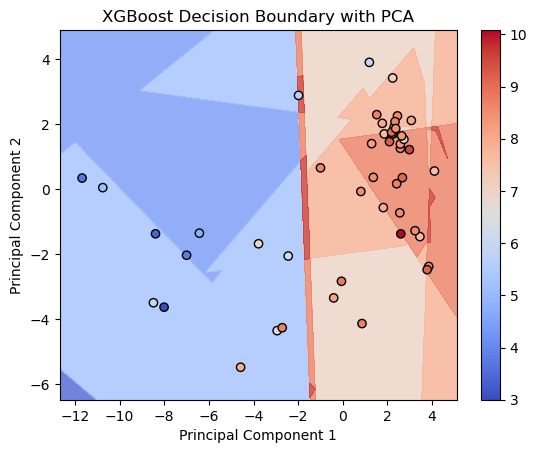

In [19]:
X_train, X_test, y_train, y_test = split_data('NS3_4A_descriptors.csv', 'my_features_NS3_4A.csv', method='RandomForestRegressor')
optim_params = {'learning_rate': 1.9804567476691612, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8012056425761774, 'colsample_bytree': 0.9336073512037514, 'reg_alpha': 29.889343293182787, 'reg_lambda': 6.386070442053683, 'n_estimators': 972}
model = xgb.XGBRegressor(random_state=37, **optim_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test metrics")
test_metric = metrics("XGBRegressor with optim", y_test, y_pred)

print('_______________________________________________________________')
print("Train metrics")
train_metric = metrics("XGBRegressor with optim", y_train, model.predict(X_train))

plot_svr_decision_boundary(model, pca, X_test, y_test, 'XGBoost', 'XGBoost with optuna')

Test metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.5514472978636649
RMSE: 0.7079105385134609
R²: 0.8152187895442852
Pearson correlation coefficient: 0.9029368276387799, p-value: 7.382281791655911e-19

_______________________________________________________________
Train metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.43035718515537874
RMSE: 0.6115382108009066
R²: 0.8259355960788626
Pearson correlation coefficient: 0.9095868184250729, p-value: 2.1193851269419098e-168



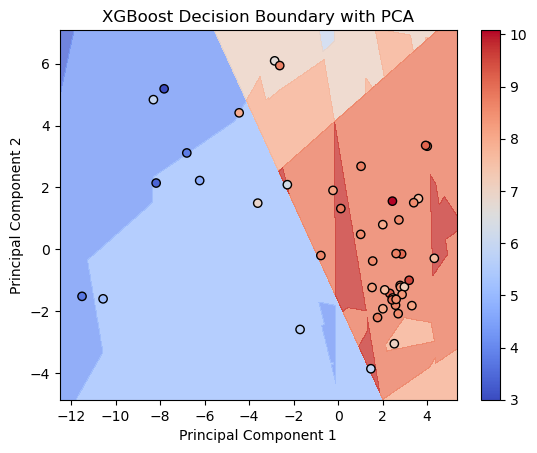

In [176]:
optim_params = {'learning_rate': 2, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 30, 'reg_lambda': 6.4, 'n_estimators': 972}
model = xgb.XGBRegressor(random_state=37, **optim_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test metrics")
test_metric = metrics("XGBRegressor with optim", y_test, y_pred)

print('_______________________________________________________________')
print("Train metrics")
train_metric = metrics("XGBRegressor with optim", y_train, model.predict(X_train))
plot_svr_decision_boundary(model, pca, X_test, y_test, 'XGBoost')

Test metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.5471490570432204
RMSE: 0.7080710261085962
R²: 0.8151349980142176
Pearson correlation coefficient: 0.9032425671144942, p-value: 6.878472879265937e-19

_______________________________________________________________
Train metrics
XGBRegressor with optim. Classification metrics:

MAE: 0.4624598772599128
RMSE: 0.6277673471132122
R²: 0.8165742871808808
Pearson correlation coefficient: 0.9048190914113245, p-value: 9.060402463828141e-164



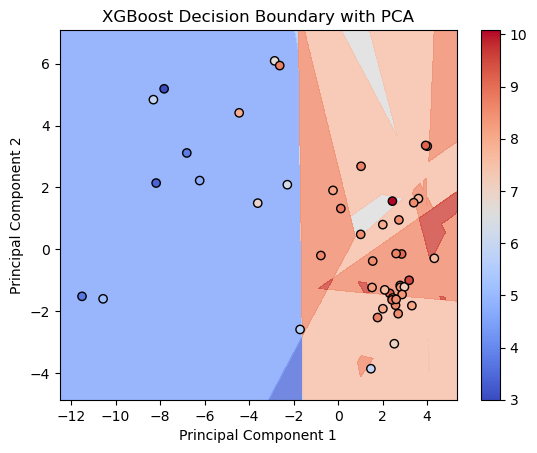

In [186]:
optim_params = {'learning_rate': 2, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.95, 'reg_alpha': 30, 'reg_lambda': 6.4, 'n_estimators': 500}
model = xgb.XGBRegressor(random_state=37, **optim_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test metrics")
test_metric = metrics("XGBRegressor with optim", y_test, y_pred)

print('_______________________________________________________________')
print("Train metrics")
train_metric = metrics("XGBRegressor with optim", y_train, model.predict(X_train))
plot_svr_decision_boundary(model, pca, X_test, y_test, 'XGBoost')

# Fully connected layers

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Используется устройство: cuda


In [35]:
# Преобразование данных в тензоры PyTorch
X_train = torch.tensor(X_train.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [36]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [73]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, hidden_size_3,
                 hidden_size_4, output_size):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size_1)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_size_2, hidden_size_3)
        self.dropout3 = nn.Dropout(0.3)
        self.fc4 = nn.Linear(hidden_size_3, output_size)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

In [78]:
input_size = X_train.shape[1]  # Количество признаков = 50
hidden_size_1, hidden_size_2, hidden_size_3, hidden_size_4  = 128, 64, 32, 16
output_size = 1  

# Инициализация модели
model = RegressionModel(input_size, hidden_size_1, hidden_size_2, hidden_size_3,
                        hidden_size_4, output_size)

model.apply(init_weights)

model = model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Определение функции потерь и оптимизатора
criterion = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.001)

# Создание DataLoader для мини-пакетного обучения
batch_size = 32
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [79]:
def elastic_net_regularization(model, lambda_l1=1e-3, lambda_l2=1e-3):
    l1_loss, l2_loss = 0.0, 0.0
    for param in model.parameters():
        l1_loss += torch.sum(torch.abs(param))  # L1
        l2_loss += torch.sum(param ** 2)        # L2
    return lambda_l1 * l1_loss + lambda_l2 * l2_loss

In [119]:
num_epochs = 4000
total_train_loss = {}
total_test_loss = {}

# Обучение модели
for epoch in range(num_epochs):
    epoch_mse = 0.0
    num_batches = 0
    model.train()
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y.view(-1, 1)) + elastic_net_regularization(model)

        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()
        
        epoch_mse += criterion(outputs, batch_y.view(-1, 1)).item()
        num_batches += 1

    # Вычисление среднего лосса по всем батчам
    avg_train_mse = epoch_mse / num_batches
    
    # Валидация
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test.view(-1, 1)).item()
    
    if (epoch+1)%400==0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train MSE: {avg_train_mse:.4f}, Test MSE: {test_loss:.4f}')
        #print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}')
        total_train_loss[epoch+1] = avg_train_mse
        total_test_loss[epoch+1] = test_loss
        
        
model.eval()
with torch.no_grad():
    y_pred = model.forward(X_test)
    
    # Изменение размерностей
    y_train = y_train.view(-1, 1)
    y_test = y_test.view(-1, 1)

    # Перенос предсказаний и тестовых данных на CPU для вычисления метрик
    y_pred = y_pred.cpu() 
    y_test = y_test.cpu()  
    mse = mean_squared_error(y_test.numpy(), y_pred.numpy())
    r2 = r2_score(y_test.numpy(), y_pred.numpy())
    
print(f"MSE: {mse}")
print(f"R2: {r2}")

Epoch [400/4000], Train MSE: 0.4687, Test MSE: 0.7127
Epoch [800/4000], Train MSE: 0.4557, Test MSE: 0.6735
Epoch [1200/4000], Train MSE: 0.4828, Test MSE: 0.6787
Epoch [1600/4000], Train MSE: 0.4108, Test MSE: 0.6667
Epoch [2000/4000], Train MSE: 0.3863, Test MSE: 0.6495
Epoch [2400/4000], Train MSE: 0.4246, Test MSE: 0.6444
Epoch [2800/4000], Train MSE: 0.4327, Test MSE: 0.6921
Epoch [3200/4000], Train MSE: 0.4263, Test MSE: 0.6537
Epoch [3600/4000], Train MSE: 0.4337, Test MSE: 0.6310
Epoch [4000/4000], Train MSE: 0.3606, Test MSE: 0.6702
MSE: 0.670229434967041
R2: 0.7528705596923828


In [120]:
def plot_metrics(train_loss, test_loss, step):

    plt.figure(figsize=(4,4))

    plt.plot(train_loss.keys(), train_loss.values(),label = 'Train', color = '#1E90FF')
    plt.plot(test_loss.keys(), test_loss.values(), label = 'Test', color = '#FF4500')
    plt.xlabel('Количество эпох') 
    plt.ylabel('MSE')  
    plt.title('Loss per epochs') 
    plt.xticks(range(0, num_epochs+1, step))
    plt.legend()

    #plt.savefig(f"Loss_1000000_epochs", bbox_inches="tight")
    plt.tight_layout()
    plt.show()  

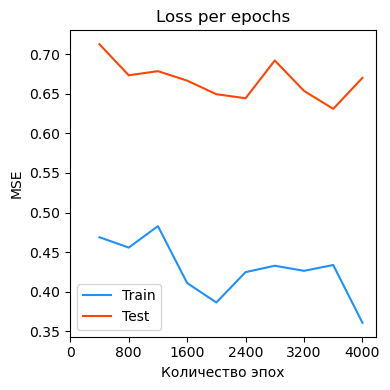

In [121]:
plot_metrics(total_train_loss,total_test_loss, step=800)

## 3 слоя

In [122]:
class ImprovedRegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size_1=64, hidden_size_2=32, output_size=1, dropout_rate=0.3):
        super().__init__()
        # Уменьшаем количество слоев и нейронов
        self.fc1 = nn.Linear(input_size, hidden_size_1)
        self.bn1 = nn.BatchNorm1d(hidden_size_1)  # Добавляем BatchNorm
        self.dropout1 = nn.Dropout(dropout_rate) 
        
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.bn2 = nn.BatchNorm1d(hidden_size_2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(hidden_size_2, output_size)
        
        # Инициализация весов
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
                nn.init.constant_(m.bias, 0.01)
    
    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

In [123]:
model = ImprovedRegressionModel(
    input_size=X_train.shape[1],
    hidden_size_1=64,  # Уменьшенный размер
    hidden_size_2=32,
    dropout_rate=0.3   # Увеличенный dropout
).to(device)

# 3. Оптимизатор с более сильной регуляризацией
optimizer = optim.AdamW(  # AdamW лучше для регуляризации
    model.parameters(),
    lr=0.0001,          # Уменьшенный learning rate
    weight_decay=0.01   # Увеличенный L2-штраф
)

In [125]:
model = model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

num_epochs = 4000

for epoch in range(num_epochs):
    model.train()
    train_mse = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Добавление шума к данным (аугментация)
        if torch.rand(1) < 0.5:  # 50% вероятность
            batch_X = batch_X + 0.01 * torch.randn_like(batch_X)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        # Полная функция потерь
        loss = criterion(outputs, batch_y.view(-1, 1)) + elastic_net_regularization(model)
        
        loss.backward()
        optimizer.step()
        
        epoch_mse += criterion(outputs, batch_y.view(-1, 1)).item()
        num_batches += 1

    # Вычисление среднего лосса по всем батчам
    avg_train_mse = epoch_mse / num_batches
    
    # Валидация
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test.view(-1, 1)).item()
    
    # Логирование
    if (epoch+1)%400==0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train MSE: {avg_train_mse:.4f}, Test MSE: {test_loss:.4f}')
        #print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}')
        total_train_loss[epoch+1] = avg_train_mse
        total_test_loss[epoch+1] = test_loss
        

model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_test_np = y_test.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()
    
    mse = mean_squared_error(y_test_np, y_pred_np)
    r2 = r2_score(y_test_np, y_pred_np)
    
    print('\nFinal Evaluation:')
    print(f'Test MSE: {mse:.4f}')
    print(f'Test R2: {r2:.4f}')

Epoch [400/4000], Train MSE: 20.0797, Test MSE: 1.2713
Epoch [800/4000], Train MSE: 11.2927, Test MSE: 0.9827
Epoch [1200/4000], Train MSE: 8.1622, Test MSE: 0.8665
Epoch [1600/4000], Train MSE: 6.5213, Test MSE: 0.8619
Epoch [2000/4000], Train MSE: 5.5010, Test MSE: 0.8588
Epoch [2400/4000], Train MSE: 4.7983, Test MSE: 0.8376
Epoch [2800/4000], Train MSE: 4.2799, Test MSE: 0.7867
Epoch [3200/4000], Train MSE: 3.8778, Test MSE: 0.8052
Epoch [3600/4000], Train MSE: 3.5568, Test MSE: 0.7772
Epoch [4000/4000], Train MSE: 3.2923, Test MSE: 0.7373

Final Evaluation:
Test MSE: 0.7373
Test R2: 0.7281


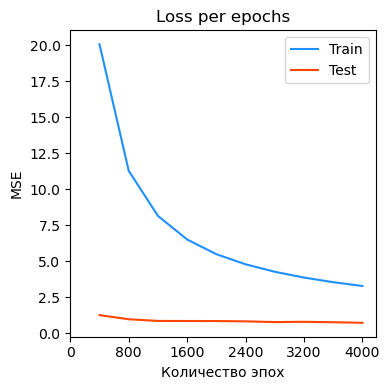

In [126]:
plot_metrics(total_train_loss,total_test_loss, step=800)

Epoch [600/6000], Train MSE: 1.8593, Test MSE: 0.7676
Epoch [1200/6000], Train MSE: 1.7724, Test MSE: 0.7049
Epoch [1800/6000], Train MSE: 1.6951, Test MSE: 0.6802
Epoch [2400/6000], Train MSE: 1.6261, Test MSE: 0.6956
Epoch [3000/6000], Train MSE: 1.5641, Test MSE: 0.6430
Epoch [3600/6000], Train MSE: 1.5082, Test MSE: 0.6480
Epoch [4200/6000], Train MSE: 1.4571, Test MSE: 0.7184
Epoch [4800/6000], Train MSE: 1.4106, Test MSE: 0.7424
Epoch [5400/6000], Train MSE: 1.3679, Test MSE: 0.7135
Epoch [6000/6000], Train MSE: 1.3287, Test MSE: 0.8847

Final Evaluation:
Test MSE: 0.8847
Test R2: 0.6738


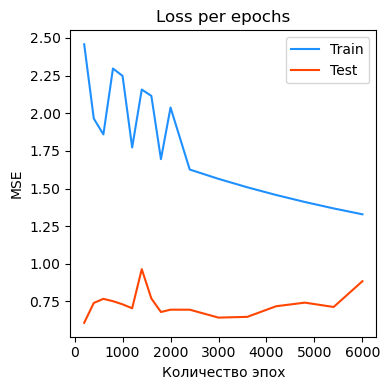

In [142]:
model = model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

num_epochs = 6000

for epoch in range(num_epochs):
    model.train()
    train_mse = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Добавление шума к данным (аугментация)
        if torch.rand(1) < 0.5:  # 50% вероятность
            batch_X = batch_X + 0.01 * torch.randn_like(batch_X)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        # Полная функция потерь
        loss = criterion(outputs, batch_y.view(-1, 1)) + elastic_net_regularization(model)
        
        loss.backward()
        optimizer.step()
        
        epoch_mse += criterion(outputs, batch_y.view(-1, 1)).item()
        num_batches += 1

    # Вычисление среднего лосса по всем батчам
    avg_train_mse = epoch_mse / num_batches
    
    # Валидация
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test.view(-1, 1)).item()
    
    # Логирование
    if (epoch+1)%(num_epochs//10)==0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train MSE: {avg_train_mse:.4f}, Test MSE: {test_loss:.4f}')
        #print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}')
        total_train_loss[epoch+1] = avg_train_mse
        total_test_loss[epoch+1] = test_loss
        

model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_test_np = y_test.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()
    
    mse = mean_squared_error(y_test_np, y_pred_np)
    r2 = r2_score(y_test_np, y_pred_np)
    
    print('\nFinal Evaluation:')
    print(f'Test MSE: {mse:.4f}')
    print(f'Test R2: {r2:.4f}')
    
plot_metrics(total_train_loss,total_test_loss, step=1000)

# Transformer

In [82]:
from torch.nn import TransformerEncoder, TransformerEncoderLayer

In [131]:
class ImprovedTransformerRegressor(nn.Module):
    def __init__(self, input_size=50, hidden_size=64, num_heads=4, 
                 num_layers=2, dropout=0.3, ff_dim=128):
        """
        Инициализация модели трансформера для регрессии.
        
        Параметры:
            input_size (int): Размер входных признаков (50)
            hidden_size (int): Размер скрытого представления 
            num_heads (int): Количество голов внимания (4 - стандартное значение)
            num_layers (int): Количество слоев трансформера (2)
            dropout (float): Вероятность дропаута (0.3)
        """
        super().__init__()
        
        self.embedding = nn.Linear(input_size, hidden_size)
        self.input_norm = nn.LayerNorm(input_size)  # Нормализация входа
        
        # Упрощенный трансформер
        encoder_layers = TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=ff_dim,  # Уменьшенный размер FFN
            dropout=dropout,
            batch_first=True,
            activation='gelu'  # Более плавная активация
        )
        self.transformer = TransformerEncoder(encoder_layers, num_layers)
        
        # Дополнительная регуляризация
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc_out = nn.Linear(hidden_size, 1)
        
        # Инициализация весов
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
                nn.init.constant_(m.bias, 0.01)

    def forward(self, x):
        x = self.input_norm(x)
        x = self.embedding(x)
        x = self.dropout(x)
        
        x = x.unsqueeze(1)  # [batch, 1, hidden_size]
        x = self.transformer(x)
        x = x.squeeze(1)
        
        x = self.layer_norm(x)
        x = self.dropout(x)
        return self.fc_out(x)

In [146]:
# Инициализация устройства (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Подготовка модели
model = TransformerRegressor(
    input_size=X_train.shape[1],  # 50 признаков как в вашем MLP
    hidden_size=64,              # Аналог hidden_size_1 в вашей модели
    num_heads=4,                 # 4 головы внимания
    num_layers=2,                # 3 слоя трансформера
    dropout=0.3                  # 10% дропаут
).to(device)

# 2. Инициализация весов (аналог вашей init_weights)
def init_weights(m):
    """Инициализация весов слоев Xavier/Glorot"""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)  # Равномерная инициализация
        m.bias.data.fill_(0.01)           # Малое смещение для избежания "мертвых нейронов"
model.apply(init_weights)

# 3. Настройка оптимизатора
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,          
    weight_decay=0.05    # L2-регуляризация
)
criterion = nn.MSELoss() 

# 4. Подготовка DataLoader 
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,    
    shuffle=True
)

In [147]:
def elastic_loss(output, target, model, lambda_l1=0.01, lambda_l2=0.01):
    mse = nn.MSELoss()(output, target)
    l1_loss = sum(p.abs().sum() for p in model.parameters())
    l2_loss = sum(p.pow(2).sum() for p in model.parameters())
    return mse + lambda_l1*l1_loss + lambda_l2*l2_loss

In [148]:
total_train_loss = {}
total_test_loss = {}

X_test = X_test.to(device)
y_test = y_test.to(device)

num_epochs = 6000

for epoch in range(num_epochs):
    # Режим обучения
    model.train()
    train_loss = 0.0
    
    # Итерация по батчам
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # Обнуляем градиенты
        optimizer.zero_grad()
        
        # Прямой проход
        outputs = model(batch_X)
        
        # Вычисление лосса (MSE)
        loss = elastic_loss(outputs, batch_y.view(-1,1), model)
        
        # Обратное распространение
        loss.backward()
        
        # Шаг оптимизации
        optimizer.step()
        
        epoch_mse += criterion(outputs, batch_y.view(-1, 1)).item()
        num_batches += 1

    # Вычисление среднего лосса по всем батчам
    avg_train_mse = epoch_mse / num_batches
    
    # Валидация
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test.view(-1, 1)).item()
    
    # Логирование
    if (epoch + 1) % (num_epochs//10) == 0:
        avg_train_loss = train_loss / len(train_loader)
        print(f'Epochs [{epoch+1}/{num_epochs}], Train MSE: {avg_train_mse:.4f}, Test MSE: {test_loss:.4f}')
        total_train_loss[epoch+1] = avg_train_mse
        total_test_loss[epoch+1] = test_loss


# Финальная оценка
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    # Перенос на CPU для метрик sklearn
    y_test_np = y_test.cpu().numpy()
    y_pred_np = y_pred.cpu().numpy()
    
    mse = mean_squared_error(y_test_np, y_pred_np)
    r2 = r2_score(y_test_np, y_pred_np)
    
    print('\nFinal metrics:')
    print(f'MSE: {mse:.4f}')  # Среднеквадратичная ошибка
    print(f'R2: {r2:.4f}')    # Коэффициент детерминации

Epochs [600/6000], Train MSE: 1.0867, Test MSE: 0.5911
Epochs [1200/6000], Train MSE: 1.0802, Test MSE: 0.7092
Epochs [1800/6000], Train MSE: 1.0754, Test MSE: 0.8784
Epochs [2400/6000], Train MSE: 1.0738, Test MSE: 0.7561
Epochs [3000/6000], Train MSE: 1.0711, Test MSE: 0.6660
Epochs [3600/6000], Train MSE: 1.0712, Test MSE: 0.8891
Epochs [4200/6000], Train MSE: 1.0694, Test MSE: 0.8617
Epochs [4800/6000], Train MSE: 1.0669, Test MSE: 0.7857
Epochs [5400/6000], Train MSE: 1.0657, Test MSE: 0.8087
Epochs [6000/6000], Train MSE: 1.0716, Test MSE: 0.7668

Final metrics:
MSE: 0.7668
R2: 0.7173


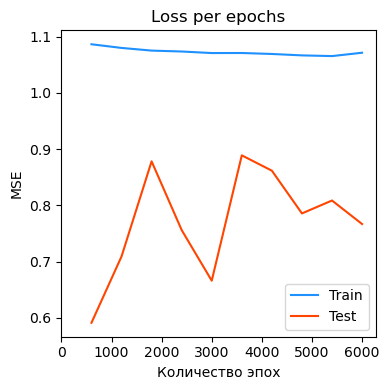

In [149]:
plot_metrics(total_train_loss,total_test_loss, step=1000)

# Validation

In [155]:
X_train, X_test, y_train, y_test = split_data('~/ML/HCV/NS3_4A_working/validation/descriptors_approved.csv', 'my_features_NS3_4A.csv', method='RandomForestRegressor')

KeyError: "['P2m', 'FP51', 'FP165', 'FP434', 'ExtFP1017', 'KRFP347', 'KRFPC347', 'APC2D8_N_O'] not in index"

In [ ]:
optim_params = {'learning_rate': 1.9804567476691612, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8012056425761774, 'colsample_bytree': 0.9336073512037514, 'reg_alpha': 29.889343293182787, 'reg_lambda': 6.386070442053683, 'n_estimators': 972}
model = xgb.XGBRegressor(random_state=37, **optim_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test metrics")
test_metric = metrics("XGBRegressor with optim", y_test, y_pred)

print('_______________________________________________________________')
print("Train metrics")
train_metric = metrics("XGBRegressor with optim", y_train, model.predict(X_train))

plot_svr_decision_boundary(model, pca, X_test, y_test, 'XGBoost')